In [1]:

# Install requred packeges
import ee
import geemap
import matplotlib.pyplot as plt
from geemap import chart as geemap_chart
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [2]:
# !pip install -U google-earthengine google-genai
# import ee
# from google.genai import client, types
# from google.colab import userdata

# Cell 1: Install required packages
!pip install -U earthengine-api google-generativeai pillow requests

import ee
import google.generativeai as genai
from google.colab import userdata
import requests
from PIL import Image
from io import BytesIO

ERROR: Could not find a version that satisfies the requirement google-earthengine (from versions: none)
ERROR: No matching distribution found for google-earthengine


In [3]:
"""
PandasAgent — drop-in replacement for LangChain's create_pandas_dataframe_agent.

Works directly against the Gemini API (google-generativeai SDK, already installed in
the notebook). Two modes:
  - 'context'  : serialise the whole DataFrame into the prompt and let the model reason
                 directly. Best for small DataFrames (< ~500 rows). Zero risk from exec().
  - 'codegen'  : ask the model to write Python, execute it locally, return the result.
                 Equivalent to what LangChain was attempting, but without the broken
                 function-calling plumbing.

Usage (drop-in for the last cells of the notebook):

    from pandas_agent import PandasAgent

    agent = PandasAgent(df=mean_rainfall_df, api_key=GEMINI_API_KEY)
    print(agent.invoke("Which year had the highest rainfall?"))
    print(agent.invoke("Plot a bar chart of mean rainfall by year"))  # codegen mode
"""

import io
import re
import sys
import traceback

import pandas as pd


# ── helpers ──────────────────────────────────────────────────────────────────

def _df_summary(df: pd.DataFrame) -> str:
    buf = io.StringIO()
    df.info(buf=buf)
    return (
        f"Shape: {df.shape}\n"
        f"Columns: {list(df.columns)}\n"
        f"Dtypes:\n{df.dtypes.to_string()}\n\n"
        f"Head (5 rows):\n{df.head().to_string()}\n\n"
        f"Describe:\n{df.describe().to_string()}"
    )


def _strip_fences(text: str) -> str:
    """Remove ```python … ``` or ``` … ``` fences the model may add."""
    text = text.strip()
    text = re.sub(r"^```(?:python)?\s*", "", text)
    text = re.sub(r"\s*```$", "", text)
    return text.strip()


# ── core class ────────────────────────────────────────────────────────────────

class PandasAgent:
    """
    Parameters
    ----------
    df          : pandas DataFrame to query.
    api_key     : Google Gemini API key.
    model       : Gemini model name.  'gemini-2.0-flash' is stable with tool-free calls.
                  Avoid 'gemini-2.5-flash' for now — confirmed broken with LangChain
                  function-calling, and still unreliable in multi-turn tool use.
    mode        : 'context' (default for <= context_row_limit rows) or 'codegen'.
    context_row_limit : rows threshold; above this, automatically use 'codegen'.
    verbose     : print generated code before executing (codegen mode only).
    """

    def __init__(
        self,
        df: pd.DataFrame,
        api_key: str,
        model: str = "gemini-2.0-flash",
        mode: str = "auto",
        context_row_limit: int = 300,
        verbose: bool = True,
    ):
        try:
            import google.generativeai as genai
        except ImportError:
            raise ImportError(
                "google-generativeai not installed. "
                "Run: pip install -U google-generativeai"
            )

        genai.configure(api_key=api_key)
        self._genai = genai
        self._model_name = model
        self._model = genai.GenerativeModel(model)
        self.df = df
        self.verbose = verbose

        if mode == "auto":
            self.mode = "context" if len(df) <= context_row_limit else "codegen"
        else:
            self.mode = mode

        self._summary = _df_summary(df)

    # ── public ────────────────────────────────────────────────────────────────

    def invoke(self, question: str) -> str:
        """Answer a natural-language question about the DataFrame."""
        if self.mode == "context":
            return self._context_invoke(question)
        return self._codegen_invoke(question)

    # ── private: context mode ─────────────────────────────────────────────────

    def _context_invoke(self, question: str) -> str:
        prompt = (
            "You are a data analyst. Below is a pandas DataFrame.\n\n"
            f"--- DataFrame info ---\n{self._summary}\n\n"
            f"--- Full data ---\n{self.df.to_string()}\n\n"
            f"Question: {question}\n\n"
            "Answer concisely and precisely. "
            "If the answer is a single value, just state it. "
            "If it involves a list or comparison, be brief."
        )
        response = self._model.generate_content(prompt)
        return response.text.strip()

    # ── private: codegen mode ─────────────────────────────────────────────────

    def _codegen_invoke(self, question: str) -> str:
        prompt = (
            "You are a Python data analyst. "
            "Write executable Python code to answer the question below.\n\n"
            f"--- DataFrame info ---\n{self._summary}\n\n"
            "The DataFrame is available as `df` (already loaded — do not reload it).\n"
            "Store your final answer in a variable called `result` AND print it.\n"
            "If the question asks for a plot, use matplotlib and call plt.show().\n"
            "Output ONLY raw Python — no markdown fences, no prose, no comments.\n\n"
            f"Question: {question}"
        )
        response = self._model.generate_content(prompt)
        code = _strip_fences(response.text)

        if self.verbose:
            print("── generated code ──────────────────────────────")
            print(code)
            print("────────────────────────────────────────────────")

        return self._exec(code)

    def _exec(self, code: str) -> str:
        """Execute code with the DataFrame in scope; return printed output or `result`."""
        import matplotlib.pyplot as plt
        import numpy as np

        local_vars: dict = {
            "df": self.df,
            "pd": pd,
            "np": np,
            "plt": plt,
        }
        buf = io.StringIO()
        old_stdout = sys.stdout
        sys.stdout = buf
        try:
            exec(code, local_vars)  # noqa: S102
            sys.stdout = old_stdout
            output = buf.getvalue().strip()
            if "result" in local_vars:
                result = local_vars["result"]
                return str(result) if output == "" else f"{output}\n{result}"
            return output or "(code ran, no output)"
        except Exception:
            sys.stdout = old_stdout
            return f"Execution error:\n{traceback.format_exc()}"


# ── convenience wrapper (matches LangChain call-site) ─────────────────────────

def create_pandas_agent(
    df: pd.DataFrame,
    api_key: str,
    model: str = "gemini-2.0-flash",
    verbose: bool = True,
) -> PandasAgent:
    """
    Mirrors the LangChain pattern:

        agent = create_pandas_agent(df=mean_rainfall_df, api_key=GEMINI_API_KEY)
        agent.invoke("Which year had the highest rainfall?")
    """
    return PandasAgent(df=df, api_key=api_key, model=model, verbose=verbose)

In [8]:

# Authenticate and Initialize Earth Engine
ee.Authenticate()
ee.Authenticate(force=True)
ee.Initialize(project="astral-comfort-237012")


In [9]:
import google.generativeai as genai
from google.colab import userdata

# Gemini
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY').strip()
genai.configure(api_key=GEMINI_API_KEY) # Configure the API key using genai.configure()

# Test if API is working
model = genai.GenerativeModel('gemini-1.5-flash')
print("Gemini API configured successfully!")

Gemini API configured successfully!


In [10]:
# Cell 4: Load Earth Engine image and get thumbnail
image = ee.Image('USGS/SRTMGL1_003')
region = ee.Geometry.Point([36.8, -1.3]).buffer(10000)

# Generate URL for a thumbnail
url = image.getThumbURL({
    'region': region,
    'min': 0,
    'max': 3000,
    'dimensions': 512,
    'format': 'png'
})

print(f"Thumbnail URL: {url}")

# Download the image from the URL
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Optionally display the image
img.show()

Thumbnail URL: https://earthengine.googleapis.com/v1/projects/astral-comfort-237012/thumbnails/8fca5b31e8818361c4fc38c52029a1e1-990146fc36e2fc65dd7d483271b212b8:getPixels


In [12]:
# response = gemini_client.models.generate_content(
#     model='gemini-2.5-flash', # Or current model name [1]
#     contents=[
#         types.Content(
#             role='user',
#             parts=[
#                 types.Part.from_uri(file_uri=url, mime_type='image/png'),
#                 types.Part.from_text(text='Describe this terrain based on elevation data.')
#             ]
#         )
#     ]
# )
# print(response.text)

# Cell 5: Use Gemini to analyze the image
# Configure the genai library with the API key
genai.configure(api_key=GEMINI_API_KEY)

# Initialize the model
model = genai.GenerativeModel('gemini-2.5-flash')

# Download the image as PIL Image object
response_img = requests.get(url)
img = Image.open(BytesIO(response_img.content))

# Generate content with the image
response = model.generate_content([
    "Describe this terrain based on elevation data. What are the key features you can observe?",
    img
])

print(response.text)

Based on the elevation data presented in the grayscale image, where lighter shades generally indicate higher elevation and darker shades indicate lower elevation, the terrain can be described as follows:

**Overall Character:**

The most striking feature is the **extremely low relief** and **minimal variation in elevation** across the entire depicted area. The terrain appears predominantly **flat to very gently undulating**. The elevation changes are so subtle that they are barely perceptible without close inspection and are magnified by the cropped images.

**Key Features Observed:**

1.  **Vast, Gentle Plains/Plateaus:** The majority of the image is covered by a uniform mid-gray tone, indicating extensive areas of relatively consistent, mid-level elevation. This suggests large, expansive plains or very broad, flat plateaus.
2.  **Subtle, Elongated Rises or Ridges:** In the upper half of the image, particularly noticeable when examining the cropped views, there are very faint, wavy, l

The NotFound error for gemini-pro-vision suggests that your Google Cloud Project or API key might not have proper access or permissions to use this model. This often points to the Generative Language API not being enabled in your Google Cloud Project, or your API key lacking the necessary IAM permissions. I recommend checking your Google Cloud Project settings to ensure the Generative Language API is enabled and that your service account has the correct roles. You can also try listing the available models to verify if gemini-pro-vision is accessible to your project.

End of Trials

In [15]:

# Authenticate and Initialize Earth Engine
ee.Authenticate()
ee.Authenticate(force=True)
ee.Initialize(project="astral-comfort-237012")


In [16]:
import ee
import geemap

# Create region of interst
Map = geemap.Map()
polygon_geometry = ee.Geometry.Polygon(
    [[[36.0502252757208, -0.5410977865278568],
      [36.5336237132208, -0.5410977865278568],
      [36.5336237132208, -0.20876894220282527],
      [36.0502252757208, -0.20876894220282527],
      [36.0502252757208, -0.5410977865278568]]]);

# Wrap the geometry in a FeatureCollection
counties = ee.FeatureCollection([ee.Feature(polygon_geometry, {'name': 'Defined Region'})])

# Define region using the provided geometry
region = counties # This 'region' variable is used for global filterBounds in some cells
Map.centerObject(polygon_geometry, 12)
Map.add_basemap('SATELLITE')
#Map

In [17]:
# Define time period
start_date = '2004-01-01'
end_date = '2020-12-31'

#### Deal with CHIRPS

In [18]:
# Load CHIRPS rainfall dataset
chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
    .filterDate(start_date, end_date) \
    #.filterBounds(ee_centroid)
#print(f"CHIRPS collection size: {chirps.size().getInfo()} images")

# Calculate monthly rainfall
def monthly_rainfall(year, month):
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, 'month')

    monthly_sum = chirps.filterDate(start, end) \
                        .select('precipitation') \
                        .sum() \
                        .set('year', year) \
                        .set('month', month) \
                        .set('system:time_start', start.millis())

    return monthly_sum

# Generate monthly composites and return an ImageCollection
def generate_monthly_rainfall_collection():
    years = ee.List.sequence(2004, 2020)
    months = ee.List.sequence(1, 12)

    monthly_images = years.map(lambda year:
        months.map(lambda month: monthly_rainfall(year, month))
    ).flatten()

    return ee.ImageCollection.fromImages(monthly_images)

# Extract time series for a given band (This function is now part of DroughtMonitor class)
# def extract_time_series(self, collection, band_name, scale=1000):
#     """Extract time series data for each county"""

#     def extract_values(image):
#         # Get image date
#         date = image.get('system:time_start')

#         # Calculate mean values for each county
#         county_values = image.select(band_name).reduceRegions(
#             collection=self.counties,
#             reducer=ee.Reducer.mean(),
#             scale=scale
#         )

#         # Add date to each feature
#         return county_values.map(lambda feature: feature.set('date', date))

#     # Map over image collection
#     time_series = collection.map(extract_values).flatten()

#     return time_series

In [19]:
Map.addLayer(chirps, {'bands': ['precipitation'], 'min': 0, 'max': 100}, 'CHIRPS Precipitation')
# Map

In [20]:
# Now Let's calculate monthly rainfall and plot a time series chat
# Calculate monthly rainfall
def monthly_rainfall(year, month):
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, 'month')

    monthly_sum = chirps.filterDate(start, end) \
                        .select('precipitation') \
                        .sum() \
                        .set('year', year) \
                        .set('month', month) \
                        .set('system:time_start', start.millis())

    return monthly_sum

# Generate monthly composites and return an ImageCollection
def generate_monthly_rainfall_collection(years_list, months_list):
    monthly_images = years_list.map(lambda year:
        months_list.map(lambda month: monthly_rainfall(year, month))
    ).flatten()

    return ee.ImageCollection.fromImages(monthly_images)

# Extract time series for a given band
def extract_time_series(collection, band_name, scale, region):
    def extract_values(image):
        date = image.get('system:time_start')

        # Calculate mean values for each county
        county_values = image.select(band_name).reduceRegions(
            collection=region,
            reducer=ee.Reducer.mean(),
            scale=scale
        )

        return county_values.map(lambda feature: feature.set('date', date))

    time_series = collection.map(extract_values).flatten()
    return time_series

In [21]:
# --- PANDAS AND MATPLOTLIB FUNCTIONS ---

# Get the rainfall time series for all counties and convert to pandas DataFrame
def get_rainfall_time_series(rainfall_collection, region):
    print("Extracting rainfall time series...")
    rainfall_ts = extract_time_series(rainfall_collection, 'precipitation', 1000, region)

    # Convert to pandas DataFrame
    rainfall_data = []
    features = rainfall_ts.getInfo()['features']

    for feature in features:
        props = feature['properties']
        if 'mean' in props and props['mean'] is not None:
            rainfall_data.append({
                'County': props.get('name', 'Unknown'),
                'Date': datetime.fromtimestamp(props['date'] / 1000),
                'Rainfall': props['mean']
            })

    return pd.DataFrame(rainfall_data)

# Plot time series for multiple counties
def plot_time_series(data, value_col, title, ylabel):
    plt.figure(figsize=(15, 8))

    # Plot for all unique counties in the dataset
    for county in data['County'].unique():
        county_data = data[data['County'] == county].sort_values('Date')
        plt.plot(
            county_data['Date'],
            county_data[value_col],
            label=county,
            linewidth=1.5,
            alpha=0.8
        )

    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


Extracting rainfall time series...


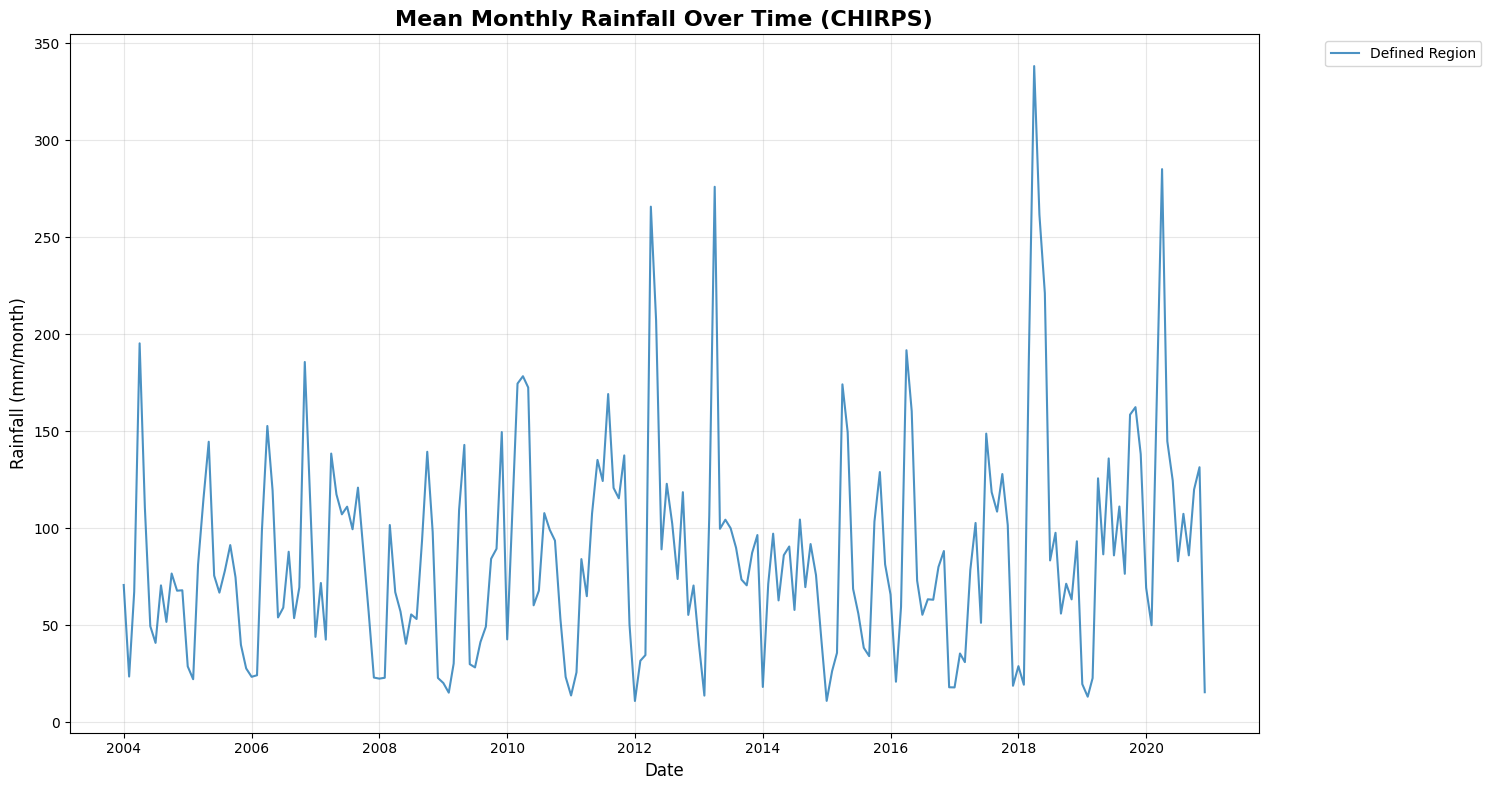

In [22]:

# --- MAIN EXECUTION BLOCK ---
if __name__ == '__main__':
    # 1. Generate the monthly rainfall collection
    years_list = ee.List.sequence(2004, 2020)
    months_list = ee.List.sequence(1, 12)
    rainfall_collection = generate_monthly_rainfall_collection(years_list, months_list)

    # 2. Get the rainfall time series and convert to a DataFrame
    rainfall_df = get_rainfall_time_series(rainfall_collection, counties)

    # 3. Plot the time series
    plot_time_series(
        data=rainfall_df,
        value_col='Rainfall',
        title='Mean Monthly Rainfall Over Time (CHIRPS)',
        ylabel='Rainfall (mm/month)'
    )

## Calculate meanrainfal per county by looping through counties

In [23]:
# funtion to loop through counties
def monthly_rainfall(year, month):
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, 'month')

    monthly_sum = chirps.filterDate(start, end) \
                        .select('precipitation') \
                        .sum() \
                        .set('year', year) \
                        .set('month', month) \
                        .set('system:time_start', start.millis())

    return monthly_sum

def generate_monthly_rainfall_collection(years_list, months_list):
    monthly_images = years_list.map(lambda year:
        months_list.map(lambda month: monthly_rainfall(year, month))
    ).flatten()

    return ee.ImageCollection.fromImages(monthly_images)

def extract_time_series(collection, band_name, scale, region):
    def extract_values(image):
        date = image.get('system:time_start')

        # Calculate mean values for each county using reduceRegions.
        # This is the key step that "loops" through all counties on the server.
        county_values = image.select(band_name).reduceRegions(
            collection=region,
            reducer=ee.Reducer.mean(),
            scale=scale
        )
        return county_values.map(lambda feature: feature.set('date', date))

    time_series = collection.map(extract_values).flatten()
    return time_series


## Extract dataframe

In [24]:
# Extract year from the 'Date' column
rainfall_df['Year'] = rainfall_df['Date'].dt.year

# Calculate the mean rainfall per year
mean_rainfall_per_year = rainfall_df.groupby('Year')['Rainfall'].mean().reset_index()

# Rename the columns for clarity
mean_rainfall_df = mean_rainfall_per_year.rename(columns={'Rainfall': 'MeanRainfall'})

# Display the resulting DataFrame
display(mean_rainfall_df)

,Year,MeanRainfall
0,2004,74.481266
1,2005,70.611471
2,2006,87.150976
3,2007,85.290608
4,2008,64.606325
5,2009,65.947291
6,2010,98.951527
7,2011,95.848192
8,2012,98.671299
9,2013,96.616077


### Use Gemini and LLM to understand the extracted data

In [27]:
agent = PandasAgent(
    df=mean_rainfall_df,
    api_key=GEMINI_API_KEY,      # already set earlier in the notebook
    model="gemini-2.5-flash",    # stable; avoid 2.5-flash for now (LangChain bug)
    verbose=True,
)

In [28]:
result = agent.invoke("Which year had the highest rainfall?")
print(result)

result = agent.invoke("What is the average annual rainfall across all years?")
print(result)

result = agent.invoke("Are there any years where rainfall was below 50mm?")
print(result)

2018
87.054291
No.


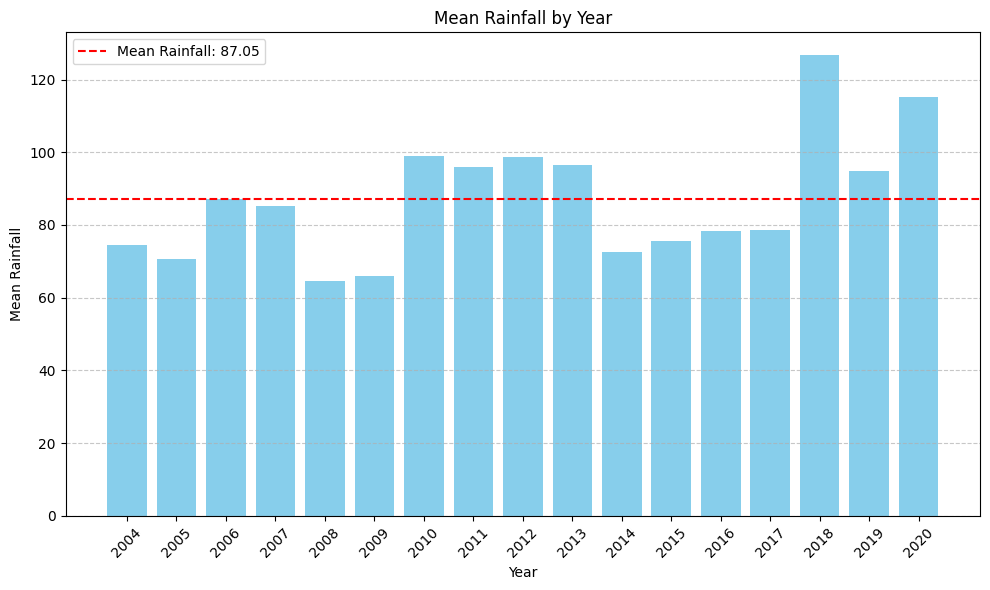

── generated code ──────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

mean_rainfall_value = df['MeanRainfall'].mean()

plt.figure(figsize=(10, 6))
plt.bar(df['Year'], df['MeanRainfall'], color='skyblue')
plt.axhline(y=mean_rainfall_value, color='red', linestyle='--', label=f'Mean Rainfall: {mean_rainfall_value:.2f}')
plt.xlabel('Year')
plt.ylabel('Mean Rainfall')
plt.title('Mean Rainfall by Year')
plt.xticks(df['Year'].unique(), rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

result = None # No specific variable to store the plot itself, the question asks to show it.
plt.show()
────────────────────────────────────────────────


'None'

In [30]:
plot_agent = PandasAgent(
    df=mean_rainfall_df,
    api_key=GEMINI_API_KEY,
    model="gemini-2.5-flash",
    mode="codegen",   # generates and executes Python code
    verbose=True,
)

plot_agent.invoke(
    "Plot a bar chart of MeanRainfall by Year. "
    "Use a blue color scheme and add a horizontal red dashed line at the mean."
)

## Calculate correlation between NDVI and rainfall

In [ ]:
# Reference

# https://medium.com/@junjunzaragosa2309/extracting-climatic-historical-data-from-google-earth-engine-using-python-api-for-a-specific-land-f2dc3b350cd7